In [1]:
from astropy.io import fits
from astropy import units, constants
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import pickle

In [2]:
rootdir = '/Users/thepoetoftwilight/Documents/Astro/Data/PG1522+101/'

Load in STIS LSF

In [3]:
lsf_fits_stis = fits.open(rootdir + 'STIS/PG1522_STIS_NUV_wavcal2022_lsf.fits')

In [4]:
lsf_fits_stis[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  

In [5]:
lsf_fits_stis[0].data

In [6]:
lsf_fits_stis[1].header

XTENSION= 'BINTABLE'           / binary table extension                         
BITPIX  =                    8 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  200 / length of dimension 1                          
NAXIS2  =                    1 / length of dimension 2                          
PCOUNT  =                    0 / number of group parameters                     
GCOUNT  =                    1 / number of groups                               
TFIELDS =                    3 / number of table fields                         
TTYPE1  = 'wave    '                                                            
TFORM1  = 'K       '                                                            
TTYPE2  = 'dv      '                                                            
TFORM2  = 'D       '                                                            
TTYPE3  = 'lsf     '        

In [7]:
lsf_fits_stis[1].data

FITS_rec([(2400, 4.9, [3.31816036e-44, 1.03829623e-36, 6.27906947e-30, 7.33870454e-24, 1.65765299e-18, 7.23632303e-14, 6.10509425e-10, 9.95444163e-07, 3.13683402e-04, 1.91036468e-02, 2.24849084e-01, 5.11465179e-01, 2.24849084e-01, 1.91036468e-02, 3.13683402e-04, 9.95444163e-07, 6.10509425e-10, 7.23632303e-14, 1.65765299e-18, 7.33870454e-24, 6.27906947e-30, 1.03829623e-36, 3.31816036e-44])],
         dtype=(numpy.record, [('wave', '>i8'), ('dv', '>f8'), ('lsf', '>f8', (23,))]))

Isolate the data - some reference wavelength, velocity scale, LSF array

In [8]:
lsf_stis_data = lsf_fits_stis[1].data

In [9]:
wav0_stis = lsf_stis_data[0][0]
dv_stis = lsf_stis_data[0][1]
lsf_arr_stis = lsf_stis_data[0][2]

In [10]:
dv_stis, len(lsf_arr_stis)

(4.9, 23)

In [11]:
idx = np.argmax(lsf_arr_stis)

In [12]:
n_pix = len(lsf_arr_stis)

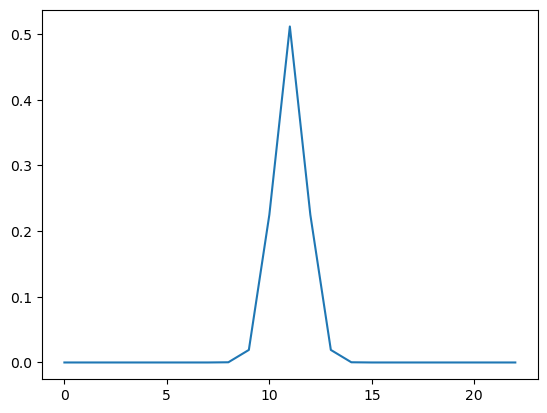

In [13]:
plt.plot(lsf_arr_stis)

In [14]:
np.argmax(lsf_arr_stis), len(lsf_arr_stis)

(11, 23)

In [15]:
np.sum(lsf_arr_stis), dv_stis*len(lsf_arr_stis)

(1.0, 112.7)

# HIRES

Prepare for STIS LSF

In [16]:
wav0_hires = 4440
dv_hires = 1.30

In [17]:
n_pix = dv_stis*len(lsf_arr_stis)//dv_hires

if n_pix%2==0:
    n_pix += 1
    
n_pix = int(n_pix)

http://personal.psu.edu/jtw13/rvworkshop/presentation/1-b-Howard-HIRES.pdf, LSF FWHM also taken from Sankar et al. 2020

In [18]:
fwhm_hires = 6.6
sigma_hires = fwhm_hires/(2*np.sqrt(2*np.log(2)))

In [19]:
x = np.arange(-(n_pix-1)//2,(n_pix-1)//2+1)*dv_hires

In [20]:
lsf_arr_hires = np.exp(-0.5*(x/sigma_hires)**2)
lsf_arr_hires /= np.sum(lsf_arr_hires)

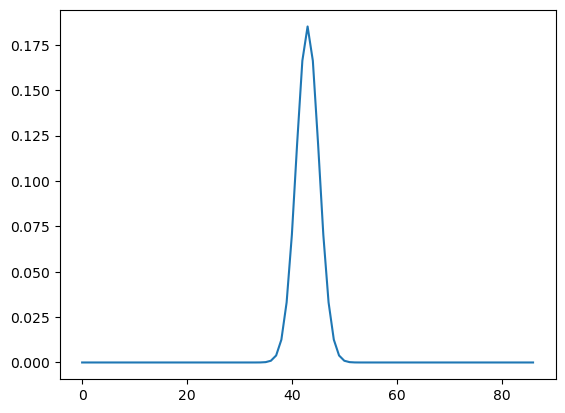

In [21]:
plt.plot(lsf_arr_hires)

In [22]:
np.argmax(lsf_arr_hires),len(lsf_arr_hires)

(43, 87)

In [23]:
c1 = fits.Column(name='wave    ', format='K', array=[wav0_hires])
c2 = fits.Column(name='dv      ', format='D', array=[dv_hires])
c3 = fits.Column(name='lsf     ', format='87D')

In [24]:
table_hdu = fits.BinTableHDU.from_columns([c1,c2,c3], nrows=1)

In [25]:
table_hdu.data[0][2] = lsf_arr_hires

In [26]:
table_hdu.data

FITS_rec([(4440, 1.3, [7.74099847e-88, 7.23908925e-84, 5.45931616e-80, 3.32016699e-76, 1.62835456e-72, 6.44028945e-69, 2.05413587e-65, 5.28348295e-62, 1.09591992e-58, 1.83317826e-55, 2.47285095e-52, 2.69003882e-49, 2.35986154e-46, 1.66948246e-43, 9.52455223e-41, 4.38202287e-38, 1.62581856e-35, 4.86448514e-33, 1.17373228e-30, 2.28385531e-28, 3.58373169e-26, 4.53492130e-24, 4.62776596e-22, 3.80838097e-20, 2.52741612e-18, 1.35263457e-16, 5.83783182e-15, 2.03184251e-13, 5.70290150e-12, 1.29083004e-10, 2.35618629e-09, 3.46830715e-08, 4.11711354e-07, 3.94126377e-06, 3.04260466e-05, 1.89418728e-04, 9.50971871e-04, 3.85016900e-03, 1.25706947e-02, 3.30983340e-02, 7.02781553e-02, 1.20337764e-01, 1.66169338e-01, 1.85040676e-01, 1.66169338e-01, 1.20337764e-01, 7.02781553e-02, 3.30983340e-02, 1.25706947e-02, 3.85016900e-03, 9.50971871e-04, 1.89418728e-04, 3.04260466e-05, 3.94126377e-06, 4.11711354e-07, 3.46830715e-08, 2.35618629e-09, 1.29083004e-10, 5.70290150e-12, 2.03184251e-13, 5.83783182e-15, 1

In [27]:
hdu = fits.HDUList([lsf_fits_stis[0], table_hdu])

In [28]:
hdu.writeto(rootdir +'HIRES/PG1522_HIRES_wavcal2023_lsf.fits', overwrite=True)